# hot-CNO and breakout

In [1]:
import pynucastro as pyna

In [2]:
rl = pyna.ReacLibLibrary()

## Transition from CNO to hot-CNO

We'll start with nuclei involved in main CNO and hot-CNO cycles.  We won't worry about the CNO-II, CNO-III, and variations of hot-CNO.

Also, we'll remove the 3-$\alpha$ rate, since it is not dominant at the temperatures we are considering here.

In [3]:
linking_nuclei = ["p", "he4",
                  "c12", "c13",
                  "n13", "n14", "n15",
                  "o14", "o15",]
lib = rl.linking_nuclei(linking_nuclei, with_reverse=False)
r3a = lib.get_rate_by_name("he4(aa,g)c12")
lib.remove_rate(r3a)

In [4]:
rc = pyna.RateCollection(libraries=lib)

To evaluate the rates, we need a composition.  This is defined using a list of `Nucleus` objects.  

In [5]:
comp = pyna.Composition(rc.get_nuclei())
comp.set_solar_like()

Let's look at the CNO cycle at a temperature and density just a bit hotter than the Sun's core

In [6]:
T = 2.e7
rho = 200

When we plot, we'll use a cut on the rates consuming a nucleus, to only show those within 5% of the fastest rate.
This will hide links that are not important at the current thermodynamic conditions.

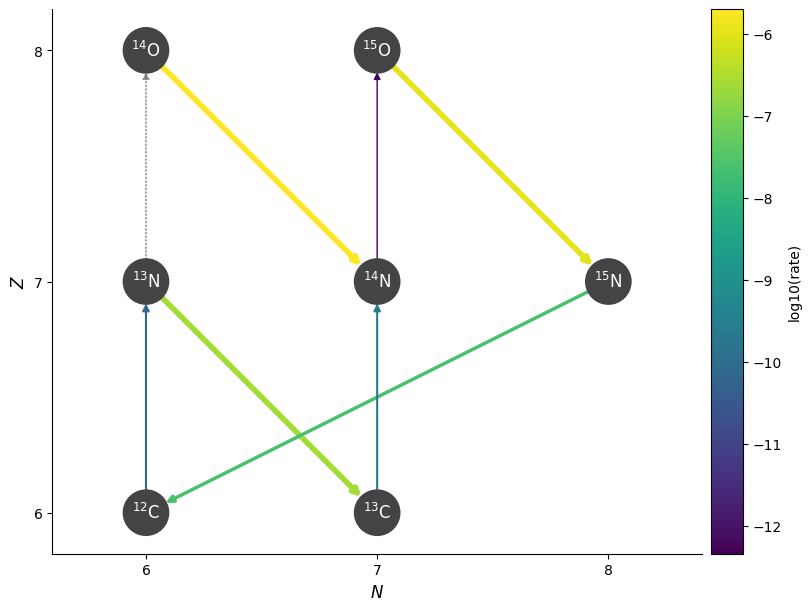

In [17]:
fig = rc.plot(rho=rho, T=T, comp=comp,
              consuming_rate_threshold=0.05,
              show_small_ydot=True,
              ydot_cutoff_value=1.e-20)

Starting at ${}^{12}\mathrm{C}$, we see the following sequence dominate:

* We capture a proton to make ${}^{13}\mathrm{N}$
* ${}^{13}\mathrm{N}$ almost immediately beta decays to ${}^{13}\mathrm{C}$, since the beta-decay rate is so much faster than a proton capture on ${}^{13}\mathrm{N}$.
* We continue with proton captures, making ${}^{14}\mathrm{N}$ and then ${}^{15}\mathrm{O}$
* ${}^{15}\mathrm{O}$ then beta-decays to get ${}^{15}\mathrm{N}$
* Finally, one last proton capture, doing ${}^{15}\mathrm{N}(p,\alpha){}^{12}\mathrm{C}$, getting us back to where we started.

This is the basic CNO cycle

Now let's make it a bit hotter

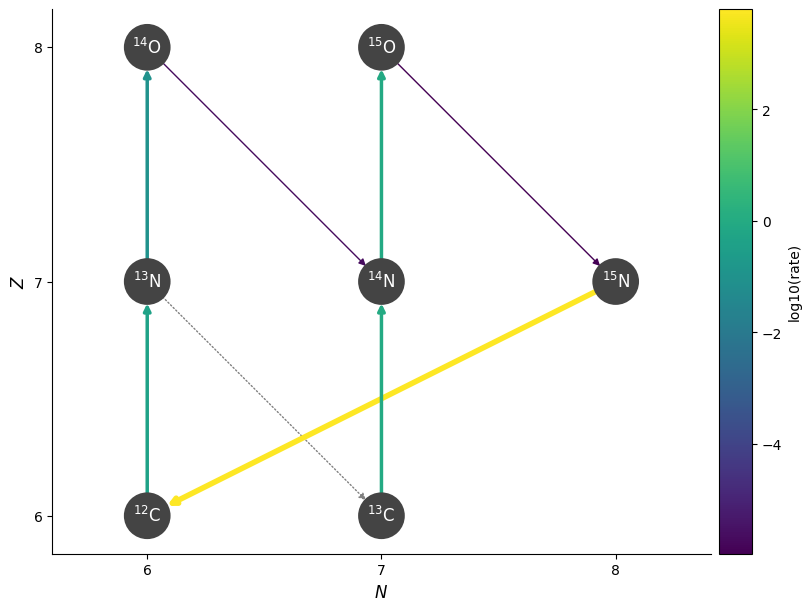

In [18]:
T = 3.e8
fig = rc.plot(rho=rho, T=T, comp=comp,
              consuming_rate_threshold=0.05,
              show_small_ydot=True,
              ydot_cutoff_value=1.e-20)

Now we see that the proton capture on ${}^{13}\mathrm{N}$ is faster than the beta-decay, and we make ${}^{14}\mathrm{O}$.  Then the cycle continues as before.

As we increase the temperature and density further, we see that the beta decays become the rate-limiting steps.

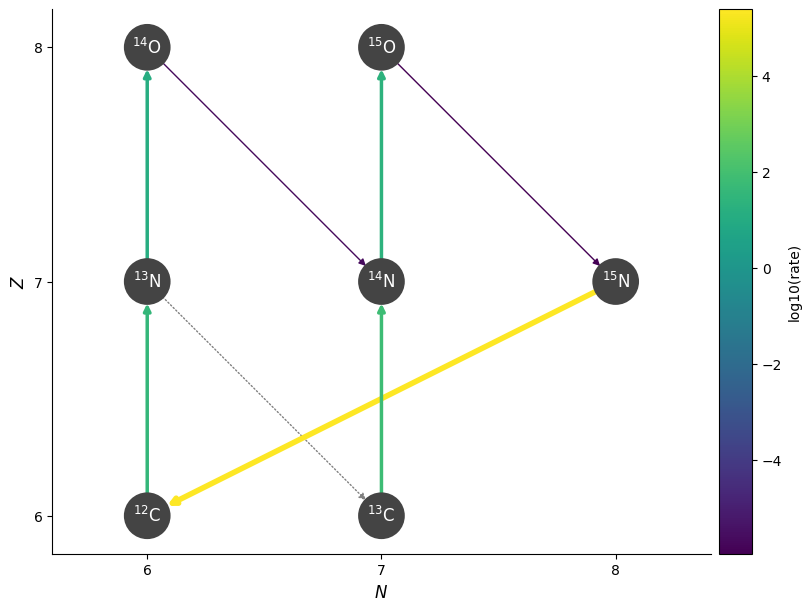

In [19]:
T = 5.e8
rho = 1.e4
fig = rc.plot(rho=rho, T=T, comp=comp,
              consuming_rate_threshold=0.05,
              show_small_ydot=True,
              ydot_cutoff_value=1.e-20)

Since the beta-decays are temperature independent (you just have to wait for the nucleus to decay), the overall hot-CNO rate becomes insensitive to temperature.

## When does hot-CNO set in?

We can look at the temperature where we cross from CNO to hot-CNO by looking at the rates involving ${}^{13}\mathrm{N}$

In [20]:
r1 = rl.get_rate_by_name("n13(p,g)o14")
r2 = rl.get_rate_by_name("n13(,)c13")

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
T = np.logspace(7.5, 8.5, 100)

rate_p_capture = [r1.eval(temp) for temp in T]
rate_beta_decay = [r2.eval(temp) for temp in T]

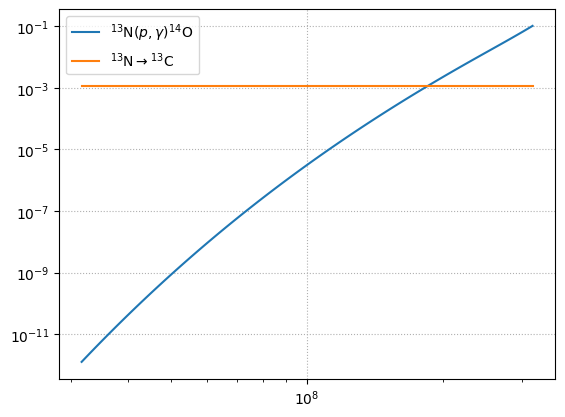

In [23]:
fig, ax = plt.subplots()
ax.plot(T, rate_p_capture, label=r"${}^{13}\mathrm{N}(p,\gamma){}^{14}\mathrm{O}$")
ax.plot(T, rate_beta_decay, label=r"${}^{13}\mathrm{N} \rightarrow {}^{13}\mathrm{C}$")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(ls=":")

We see that above $T \sim 2\times 10^8~\mathrm{K}$, the proton-capture proceeds faster than the beta-decay, and we transition to hot-CNO.

## Breakout

Let's now include some heavier nuclei to see what happens when we break out of hot-CNO

In [39]:
linking_nuclei = ["p", "he4",
                  "c12", "c13",
                  "n13", "n14", "n15",
                  "o14", "o15", "o16", "o17",
                  "f17", "f18",
                  "ne18", "ne19", "ne20"]
lib = rl.linking_nuclei(linking_nuclei, with_reverse=False)

In [40]:
rc = pyna.RateCollection(libraries=lib)

In [41]:
comp = pyna.Composition(rc.unique_nuclei)
comp.set_solar_like()

In [42]:
rho = 1.e4
T = 1.e8

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


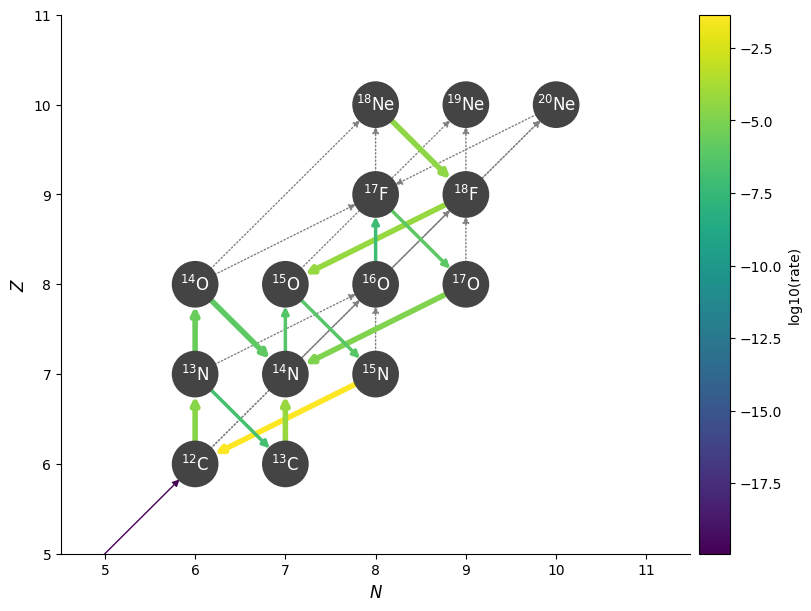

In [43]:
fig = rc.plot(rho, T, comp,
              consuming_rate_threshold=0.05,
              show_small_ydot=True,
              ydot_cutoff_value=1.e-20,
              hide_xalpha=True, hide_xp=True,
              Z_range=(5, 11), N_range=(5, 11))

We see at a temperature of $10^8~\mathrm{K}$, we stick with the hot-CNO cycle.

Now let's increase the temperature

In [44]:
T = 4.e8

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


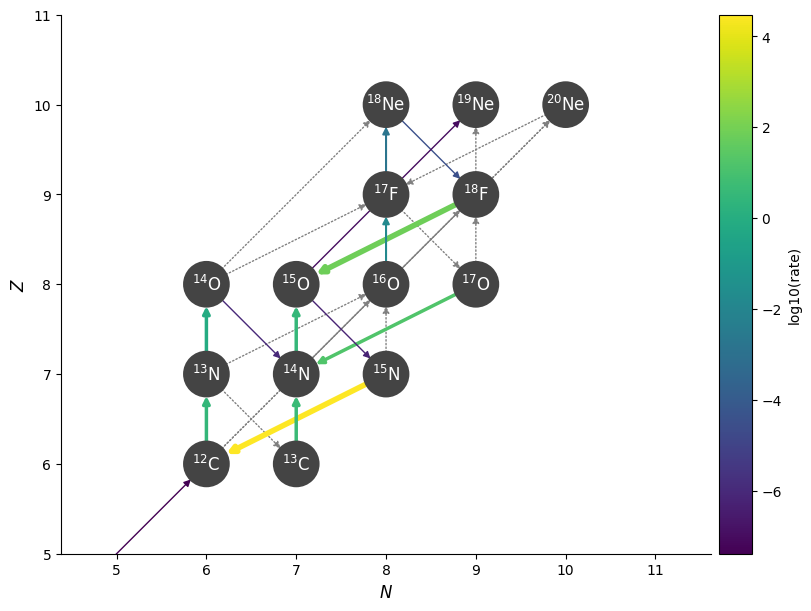

In [45]:
fig = rc.plot(rho, T, comp,
              consuming_rate_threshold=0.05,
              show_small_ydot=True,
              ydot_cutoff_value=1.e-20,
              hide_xalpha=True, hide_xp=True,
              Z_range=(5, 11), N_range=(5, 11))

Now we see that ${}^{15}\mathrm{O}(\alpha, \gamma){}^{19}\mathrm{Ne}$ is operating about as fast as the decay of ${}^{15}\mathrm{O}$, allowing us to break out of the hot-CNO cycle.